In [5]:
import pandas as pd
import numpy as np

# Example: load from CSV
# df = pd.read_csv("traffic_trace.csv")

# If already loaded, just make sure:
#df.head()

df = pd.read_csv("/home/hsd/workspace/trafpy/examples/data/link_test/com_40.csv")
df.head()

,Unnamed: 0,flow_id,sn,dn,flow_size,event_time,establish,index
0,0,flow_4401,2,0,250.0,0.000000e+00,1,0
1,1,flow_3473,2,1,700.0,8.475435e-07,1,1
2,2,flow_4185,3,0,325.0,1.695087e-06,1,2
3,3,flow_5231,1,3,75.0,4.407226e-05,1,3
4,4,flow_4123,3,0,350.0,4.491981e-05,1,4


In [6]:
#flow_size  # bytes


95% of all bytes are carried by 21.40% of flows
These flows are larger than 0.00 MB
The distribution has a very heavy tail, with 95% of all data bytes belonging to approximately 21.40% of flows that are larger than 0.00 MB.


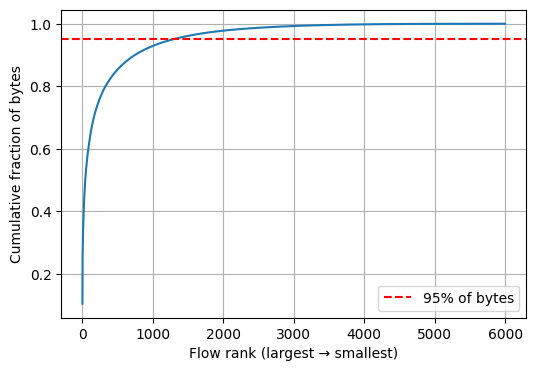

In [7]:
df_sorted = df.sort_values(by="flow_size", ascending=False).reset_index(drop=True)

total_bytes = df_sorted["flow_size"].sum()

df_sorted["cum_bytes"] = df_sorted["flow_size"].cumsum()
df_sorted["cum_fraction"] = df_sorted["cum_bytes"] / total_bytes

threshold = 0.95

idx_95 = df_sorted[df_sorted["cum_fraction"] >= threshold].index[0]

flows_for_95 = idx_95 + 1
total_flows = len(df_sorted)

percentage_of_flows = flows_for_95 / total_flows * 100

size_cutoff_bytes = df_sorted.loc[idx_95, "flow_size"]
size_cutoff_mb = size_cutoff_bytes / (8*1024 * 1024)

print(f"95% of all bytes are carried by {percentage_of_flows:.2f}% of flows")
print(f"These flows are larger than {size_cutoff_mb:.2f} MB")
print(
    f"The distribution has a very heavy tail, with 95% of all data bytes "
    f"belonging to approximately {percentage_of_flows:.2f}% of flows "
    f"that are larger than {size_cutoff_mb:.2f} MB."
)


import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(df_sorted["cum_fraction"])
plt.axhline(0.95, color="red", linestyle="--", label="95% of bytes")
plt.xlabel("Flow rank (largest → smallest)")
plt.ylabel("Cumulative fraction of bytes")
plt.legend()
plt.grid(True)
plt.show()


